# Task 1
# Data Exploration and Enrichment

 1. Import Libraries

In [23]:
# =====================================================
# Load Required Libraries
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

plt.style.use("ggplot")

2. Define Paths

In [32]:
RAW_DATA = Path("../data/raw")

excel_file = RAW_DATA / "ethiopia_fi_unified_data.xlsx"

df = pd.read_excel(
    excel_file,
    sheet_name="ethiopia_fi_unified_data"
)

impact_links = pd.read_excel(
    excel_file,
    sheet_name="Impact_sheet"
)

reference = pd.read_csv(
    RAW_DATA / "reference_codes.csv"
)

In [40]:
print(df.shape)
print(impact_links.shape)
print(reference.shape)

(43, 34)
(14, 35)
(71, 4)


3. Load Dataset

In [41]:
import pandas as pd

excel_file = "../data/raw/ethiopia_fi_unified_data.xlsx"

xls = pd.ExcelFile(excel_file)

print(xls.sheet_names)

['ethiopia_fi_unified_data', 'Impact_sheet']


In [42]:
excel_file = "../data/raw/ethiopia_fi_unified_data.xlsx"

# Main data sheet
df = pd.read_excel(
    excel_file,
    sheet_name="ethiopia_fi_unified_data"
)

# Impact links sheet
impact_links = pd.read_excel(
    excel_file,
    sheet_name="Impact_sheet"
)

# Reference codes
reference = pd.read_csv("../data/raw/reference_codes.csv")

In [43]:
print("Main Dataset Shape:", df.shape)
print("Impact Links Shape:", impact_links.shape)
print("Reference Codes Shape:", reference.shape)

Main Dataset Shape: (43, 34)
Impact Links Shape: (14, 35)
Reference Codes Shape: (71, 4)


In [44]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [45]:
impact_links.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [46]:
reference.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


In [47]:
print(reference.columns.tolist())

['field', 'code', 'description', 'applies_to']


4. Understand the schema

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     str           
 1   record_type          43 non-null     str           
 2   category             10 non-null     str           
 3   pillar               33 non-null     str           
 4   indicator            43 non-null     str           
 5   indicator_code       43 non-null     str           
 6   indicator_direction  33 non-null     str           
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     str           
 9   value_type           43 non-null     str           
 10  unit                 33 non-null     str           
 11  observation_date     43 non-null     datetime64[us]
 12  period_start         10 non-null     datetime64[us]
 13  period_end           10 non-null     datetime64[

In [49]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [50]:
df.sample(5)

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
17,REC_0018,observation,NaN,USAGE,ATM Transaction Count,USG_ATM_COUNT,neutral,119300000.0,NaN,count,transactions,2025-07-07,2024-07-08,2025-07-07,FY2024/25,all,national,NaN,EthSwitch Annual Report,operator,https://ethswitch.com/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,+26% YoY (slower than P2P),NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaT,NaT,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaT,NaT,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
15,REC_0016,observation,NaN,USAGE,P2P Transaction Count,USG_P2P_COUNT,higher_better,128300000.0,NaN,count,transactions,2025-07-07,2024-07-08,2025-07-07,FY2024/25,all,national,NaN,EthSwitch Annual Report,operator,https://ethswitch.com/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,128.3 million P2P transactions,+158% YoY growth,NaN


In [51]:
df.describe(include="all")

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
count,43,43,10,33,43,43,33,3.300000e+01,10,43,33,43,10,10,43.0,43,43,0.0,43,43,31,43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43,43,10,33,0.0
unique,43,3,7,4,29,29,3,NaN,3,6,8,NaN,NaN,NaN,13.0,3,1,NaN,25,7,8,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,10,32,NaN
top,REC_0001,observation,product_launch,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,Launched,percentage,%,NaN,NaN,NaN,2024.0,all,national,NaN,Global Findex 2021,operator,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,NaN,Account ownership increased from 46% to 49%,Gender disaggregated,NaN
freq,1,30,2,16,7,7,27,NaN,7,17,16,NaN,NaN,NaN,12.0,39,43,NaN,5,15,10,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43,NaN,1,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.437258e+10,NaN,NaN,NaN,2024-05-09 02:13:57.209302,2024-02-28 04:48:00,2025-05-08 19:12:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.080000e+00,NaN,NaN,NaN,2014-12-31 00:00:00,2021-09-01 00:00:00,2024-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.400000e+01,NaN,NaN,NaN,2023-07-16 00:00:00,2024-07-08 00:00:00,2025-07-01 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.140000e+01,NaN,NaN,NaN,2024-12-31 00:00:00,2024-07-08 00:00:00,2025-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.500000e+07,NaN,NaN,NaN,2025-07-07 00:00:00,2024-07-08 00:00:00,2025-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.380000e+12,NaN,NaN,NaN,2030-12-31 00:00:00,2024-10-15 00:00:00,2025-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN


In [52]:
print(df.columns.tolist())

['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


In [53]:
reference.head(20)

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All
5,record_type,forecast,Predicted future value,All
6,category,product_launch,New product or service introduced,event
7,category,market_entry,New competitor enters market,event
8,category,market_exit,Competitor leaves market,event
9,category,policy,Government strategy or regulatory framework,event


5. Explore the data

In [54]:
#Record types
df["record_type"].value_counts()

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

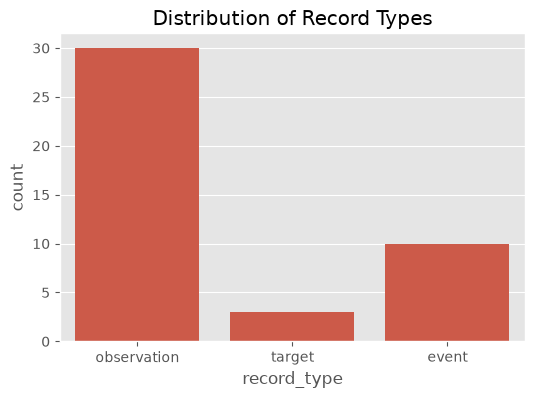

In [55]:
#Visualization
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="record_type"
)

plt.title("Distribution of Record Types")

plt.show()

In [56]:
#Pillars
df["pillar"].value_counts(dropna=False)

pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

In [57]:
#Source Types
df["source_type"].value_counts(dropna=False)

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

In [58]:
#Confidence
df["confidence"].value_counts(dropna=False)

confidence
high      40
medium     3
Name: count, dtype: int64

## Dataset Composition and Metadata Analysis

The initial exploration of the financial inclusion dataset provides an overview of its structure and quality. The dataset contains **43 records**, comprising **30 observation records**, **10 event records**, and **3 target records**. Observation records account for the majority of the dataset (approximately 70%), indicating that the data is primarily composed of measured financial inclusion indicators collected from surveys, operators, and regulatory reports. Event records capture important milestones such as policy changes, product launches, and market developments, while target records represent official financial inclusion goals that can later be compared with forecasting results.

The distribution of record types is illustrated in the accompanying bar chart, where observation records clearly dominate the dataset. This distribution is expected because the primary objective of the project is to model and forecast financial inclusion indicators using historical observations. Events and targets provide contextual information that supports later impact analysis and forecasting rather than serving as the main analytical data.

Analysis of the **financial inclusion pillars** shows that the **ACCESS** pillar contains the largest number of records (**16**), followed by the **USAGE** pillar (**11**). The dataset also includes **5 GENDER**-related records and **1 AFFORDABILITY** record. Additionally, **10 records have no assigned pillar**, which mainly corresponds to event records. This is consistent with the unified schema design, where events are intentionally not assigned to a specific pillar because their effects are modeled separately through the **Impact Sheet** using `parent_id` relationships. This design minimizes bias and allows a single event to influence multiple financial inclusion indicators.

The dataset integrates information from a variety of **source types**, increasing its reliability and comprehensiveness. **Operator reports (15 records)** represent the largest source category, reflecting the importance of mobile network operators and financial service providers in Ethiopia's digital financial ecosystem. **Survey data (10 records)** provides nationally representative financial inclusion indicators, while **regulatory sources (7 records)** contribute official statistics and policy information. Additional evidence is obtained from **research publications (4 records)**, **policy documents (3 records)**, **calculated indicators (2 records)**, and **news sources (2 records)**, ensuring that both quantitative measurements and contextual information are available for subsequent analysis.

The **confidence assessment** indicates that the dataset is highly reliable. Out of the 43 records, **40 records (approximately 93%)** are classified as **high confidence**, while only **3 records** are classified as **medium confidence**. The predominance of high-confidence records suggests that most information originates from authoritative sources such as the World Bank, the National Bank of Ethiopia, telecommunications operators, and official research publications. Consequently, the dataset provides a strong and credible foundation for exploratory data analysis, event impact assessment, and financial inclusion forecasting.

6. Observation Analysis

In [59]:
#Filter
observations = df[
    df["record_type"] == "observation"
].copy()

In [60]:
#Number
observations.shape

(30, 34)

In [61]:
#Unique indicators
observations["indicator_code"].unique()

<StringArray>
[     'ACC_OWNERSHIP',     'ACC_MM_ACCOUNT',         'ACC_4G_COV',
     'ACC_MOBILE_PEN',          'ACC_FAYDA',      'USG_P2P_COUNT',
      'USG_P2P_VALUE',      'USG_ATM_COUNT',      'USG_ATM_VALUE',
      'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE',
    'USG_MPESA_USERS',   'USG_MPESA_ACTIVE',    'USG_ACTIVE_RATE',
    'AFF_DATA_INCOME',        'GEN_GAP_ACC',       'GEN_MM_SHARE',
     'GEN_GAP_MOBILE']
Length: 19, dtype: str

In [62]:
#Coverage
coverage = (
    observations
    .groupby("indicator_code")
    .size()
    .sort_values(ascending=False)
)

coverage

indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_4G_COV            2
ACC_MM_ACCOUNT        2
GEN_GAP_ACC           2
USG_P2P_COUNT         2
ACC_MOBILE_PEN        1
GEN_GAP_MOBILE        1
GEN_MM_SHARE          1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_MPESA_ACTIVE      1
USG_CROSSOVER         1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

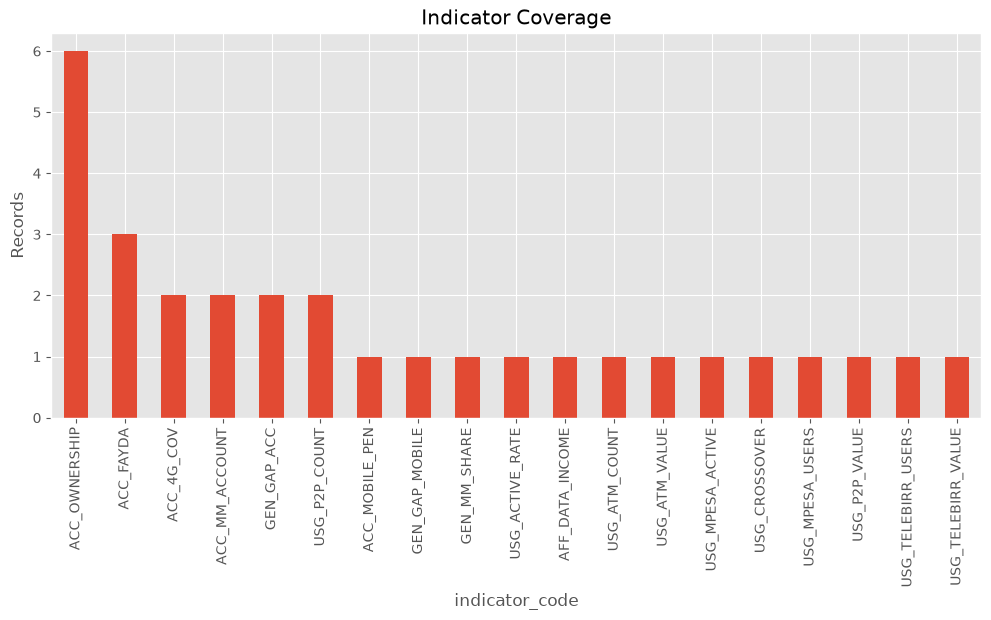

In [63]:
#Visualization
plt.figure(figsize=(12,5))

coverage.plot(kind="bar")

plt.ylabel("Records")

plt.title("Indicator Coverage")

plt.show()

In [64]:
#Temporal range
observations["observation_date"] = pd.to_datetime(
    observations["observation_date"]
)

print(
    observations["observation_date"].min()
)

print(
    observations["observation_date"].max()
)

2014-12-31 00:00:00
2025-12-31 00:00:00


## Observation Records Analysis

The dataset contains **30 observation records**, representing quantitative measurements of financial inclusion indicators collected from multiple trusted sources. These observations form the primary analytical dataset and will serve as the basis for subsequent exploratory analysis, forecasting, and event impact assessment.

A total of **19 unique financial inclusion indicators** are represented in the dataset, covering multiple dimensions of financial inclusion, including **access**, **usage**, **gender equality**, and **affordability**. The indicators include account ownership, mobile money adoption, digital payment transactions, ATM usage, mobile network coverage, digital identity (Fayda), active mobile money usage, gender disparities, and affordability-related measures. This diversity provides a comprehensive view of Ethiopia's evolving financial inclusion landscape.

The indicator coverage analysis reveals that **`ACC_OWNERSHIP` (Account Ownership)** is the most frequently recorded indicator with **6 observations**, indicating that account ownership has been consistently monitored over time and serves as one of the core indicators of financial inclusion. The **`ACC_FAYDA` (Digital Identity Registration)** indicator appears **3 times**, while **`ACC_4G_COV` (4G Coverage)**, **`ACC_MM_ACCOUNT` (Mobile Money Accounts)**, **`GEN_GAP_ACC` (Gender Gap in Account Ownership)**, and **`USG_P2P_COUNT` (Peer-to-Peer Transactions)** each appear twice. The remaining indicators have a single observation, reflecting either recently introduced metrics or indicators that are measured less frequently.

The accompanying **Indicator Coverage** chart clearly illustrates this distribution. Account ownership dominates the dataset, emphasizing its importance as the principal measure of financial inclusion. Other indicators provide complementary information on infrastructure availability, digital financial service usage, gender inclusion, affordability, and mobile money adoption. Although several indicators currently have limited observations, they contribute valuable contextual information that will support later stages of forecasting and event impact analysis.

The temporal analysis shows that the observation records span the period from **31 December 2014** to **31 December 2025**, providing approximately **11 years of historical financial inclusion data**. This extended time horizon captures significant developments in Ethiopia's digital financial ecosystem, including the expansion of mobile money services, improvements in telecommunications infrastructure, implementation of digital identity systems, and major regulatory reforms. The availability of observations across multiple years makes the dataset suitable for identifying long-term trends, evaluating the effects of major events, and supporting predictive modeling in subsequent tasks.

7. Event Analysis

In [65]:
#Filter
events = df[
    df["record_type"] == "event"
].copy()

In [66]:
#Categories
events["category"].value_counts()

category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

In [68]:
#Dates
events["observation_date"] = pd.to_datetime(
    events["observation_date"]
)

events = events.sort_values(
    "observation_date"
)

events[
    [
        "record_id",
        "category",
        "observation_date",
        "notes"
    ]
]

,record_id,category,observation_date,notes
33,EVT_0001,product_launch,2021-05-17,NaN
41,EVT_0009,policy,2021-09-01,NaN
34,EVT_0002,market_entry,2022-08-01,NaN
35,EVT_0003,product_launch,2023-08-01,NaN
36,EVT_0004,infrastructure,2024-01-01,NaN
37,EVT_0005,policy,2024-07-29,NaN
38,EVT_0006,milestone,2024-10-01,NaN
39,EVT_0007,partnership,2025-10-27,NaN
42,EVT_0010,pricing,2025-12-15,NaN
40,EVT_0008,infrastructure,2025-12-18,NaN


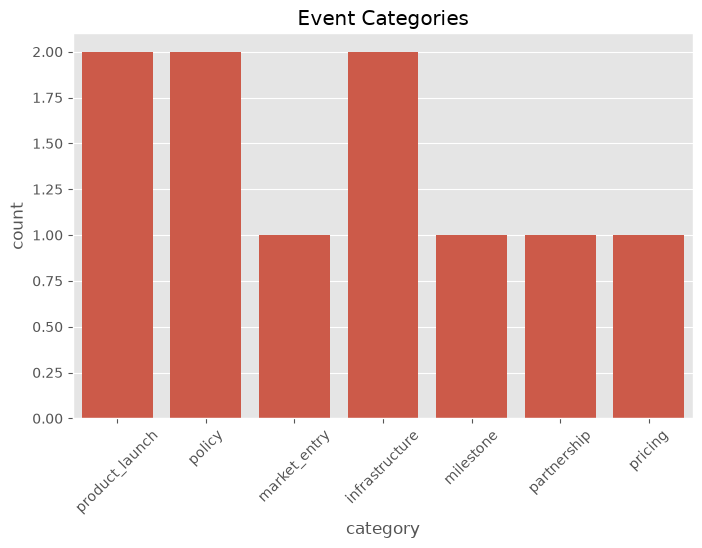

In [69]:
#Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=events,
    x="category"
)

plt.xticks(rotation=45)

plt.title("Event Categories")

plt.show()

## Event Analysis

The dataset contains **10 event records**, representing major developments that have influenced Ethiopia's financial inclusion ecosystem. Unlike observation records, which capture quantitative measurements over time, event records provide qualitative context by documenting important policy decisions, market developments, infrastructure improvements, and strategic initiatives that may affect financial inclusion indicators.

The event categories are well distributed across several aspects of the financial sector. **Product launches**, **policy initiatives**, and **infrastructure developments** each appear **twice**, making them the most common event categories in the dataset. The remaining categories—**market entry**, **milestone**, **partnership**, and **pricing**—each occur once. This balanced distribution demonstrates that the dataset captures financial inclusion from multiple perspectives, including regulatory reforms, technological advancements, competitive market expansion, and strategic collaborations.

The chronological analysis shows that the recorded events span the period from **17 May 2021** to **18 December 2025**. The earliest event corresponds to a **product launch** in May 2021, while the most recent event is an **infrastructure** development in December 2025. Between these dates, the dataset records important policy changes, market entry events, partnerships, pricing updates, and infrastructure expansions, providing a timeline of significant developments within Ethiopia's digital financial services sector.

The **Event Categories** chart further illustrates that no single category overwhelmingly dominates the dataset. Instead, the events are distributed across multiple categories, indicating that financial inclusion has been influenced by a combination of technological innovation, regulatory reforms, infrastructure investments, and private-sector initiatives rather than by a single type of intervention. This diversity is valuable for subsequent impact analysis, where different categories of events can be linked to changes in financial inclusion indicators through the Impact Sheet. Such relationships will support a more comprehensive understanding of how policy, market dynamics, and technological developments contribute to improvements in financial inclusion over time.

8. Explore Impact Links

In [70]:
impact_links.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [71]:
#Relationships
impact_links["relationship_type"].value_counts()

relationship_type
direct      9
indirect    4
enabling    1
Name: count, dtype: int64

In [72]:
#Impact direction
impact_links["impact_direction"].value_counts()

impact_direction
increase    12
decrease     2
Name: count, dtype: int64

In [73]:
#Impact magnitude
impact_links["impact_magnitude"].value_counts()

impact_magnitude
medium    8
high      5
low       1
Name: count, dtype: int64

In [74]:
#Lag
impact_links["lag_months"].describe()

count    14.000000
mean      8.428571
std       7.562196
min       1.000000
25%       3.000000
50%       6.000000
75%      12.000000
max      24.000000
Name: lag_months, dtype: float64

In [75]:
#Most affected indicators
impact_links["related_indicator"].value_counts()

related_indicator
USG_P2P_COUNT         3
AFF_DATA_INCOME       3
ACC_OWNERSHIP         2
USG_TELEBIRR_USERS    1
ACC_4G_COV            1
USG_MPESA_USERS       1
ACC_MM_ACCOUNT        1
GEN_GAP_ACC           1
USG_MPESA_ACTIVE      1
Name: count, dtype: int64

## Impact Link Analysis

The **Impact Sheet** contains the modeled relationships between major financial inclusion events and the indicators they are expected to influence. Each record represents a hypothesized or evidence-based causal relationship, linking an event (`parent_id`) to one or more financial inclusion indicators through a specified relationship type, impact direction, estimated magnitude, and expected time lag. This structure provides the foundation for understanding how policy interventions, market developments, and technological innovations may affect financial inclusion outcomes over time.

The relationship analysis shows that **direct relationships** are the most common, accounting for **9 of the 14 impact links**, followed by **4 indirect relationships** and **1 enabling relationship**. This indicates that most events are expected to have an immediate and measurable influence on specific financial inclusion indicators, while a smaller number of impacts occur indirectly through intermediate mechanisms or by creating favorable conditions for future improvements.

The impact direction analysis reveals that **12 of the 14 relationships are expected to increase financial inclusion indicators**, whereas only **2 relationships are associated with decreases**. These decreases are not necessarily negative outcomes; for example, reductions in data affordability indicators may represent lower data costs, which can positively contribute to greater access to digital financial services. Overall, the dataset reflects an optimistic view in which major financial sector interventions are expected to improve financial inclusion across multiple dimensions.

The estimated impact magnitudes further indicate that the majority of relationships are expected to have **medium impacts (8 records)**, followed by **high impacts (5 records)** and only **one low-impact relationship**. This distribution suggests that most interventions are anticipated to produce meaningful, but not necessarily transformative, changes in financial inclusion indicators.

The lag analysis shows that event impacts are generally expected to materialize over relatively short to medium-term periods. The average estimated lag is approximately **8.4 months**, with values ranging from **1 month to 24 months**. Half of the modeled impacts occur within **6 months**, while 75% are expected within **12 months**, indicating that many policy and market interventions are assumed to influence financial inclusion indicators within one year.

Analysis of the affected indicators shows that **`USG_P2P_COUNT` (Peer-to-Peer Transaction Count)** and **`AFF_DATA_INCOME` (Data Affordability)** are the most frequently linked indicators, each appearing **three times**. **`ACC_OWNERSHIP` (Account Ownership)** appears twice, while indicators such as **`USG_TELEBIRR_USERS`**, **`ACC_4G_COV`**, **`USG_MPESA_USERS`**, **`ACC_MM_ACCOUNT`**, **`GEN_GAP_ACC`**, and **`USG_MPESA_ACTIVE`** each appear once. This distribution indicates that the modeled events primarily target digital payment activity, affordability, and financial access, while also capturing broader impacts on infrastructure, gender inclusion, and mobile money adoption.

Overall, the Impact Sheet complements the observation and event datasets by introducing explicit causal assumptions between events and financial inclusion indicators. These relationships provide valuable contextual knowledge that can later support forecasting, scenario analysis, and evaluation of how major interventions may influence Ethiopia's financial inclusion ecosystem.